In [1]:
import pandas as pd

train_df = pd.read_parquet("chebi_dataset_train.parquet")
test_df  = pd.read_parquet("chebi_dataset_test_empty.parquet")
print(f"Train: {train_df.shape}, Test: {test_df.shape}")
train_df.head(3)

Train: (33668, 502), Test: (11223, 2)


,mol_id,SMILES,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,...,class_490,class_491,class_492,class_493,class_494,class_495,class_496,class_497,class_498,class_499
0,mol_12500,CCCCC/C=C\CCCCCCCC(=O)O,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,mol_15962,Cc1cc2cc(O)cc(O)c2c(C)n1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,mol_42147,C[C@H](CCC[C@@H](C)C=O)[C@H]1CC[C@H]2[C@@H]3CC...,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


# Parse OBO → build class DAG

In [2]:
import networkx as nx

def parse_obo_to_graph(path: str) -> nx.DiGraph:
    """Parse OBO 1.4 file and return a DiGraph with edges parent -> child."""
    G = nx.DiGraph()
    current_id = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line == "[Term]":
                current_id = None
            elif line.startswith("id:"):
                current_id = line.split("id:", 1)[1].strip()
                G.add_node(current_id)
            elif line.startswith("is_a:") and current_id:
                parent = line.split("is_a:", 1)[1].strip().split()[0]
                G.add_edge(parent, current_id)   # parent -> child
    return G

G = parse_obo_to_graph("chebi_classes.obo")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(G)}")

Nodes: 500, Edges: 748
Is DAG: True


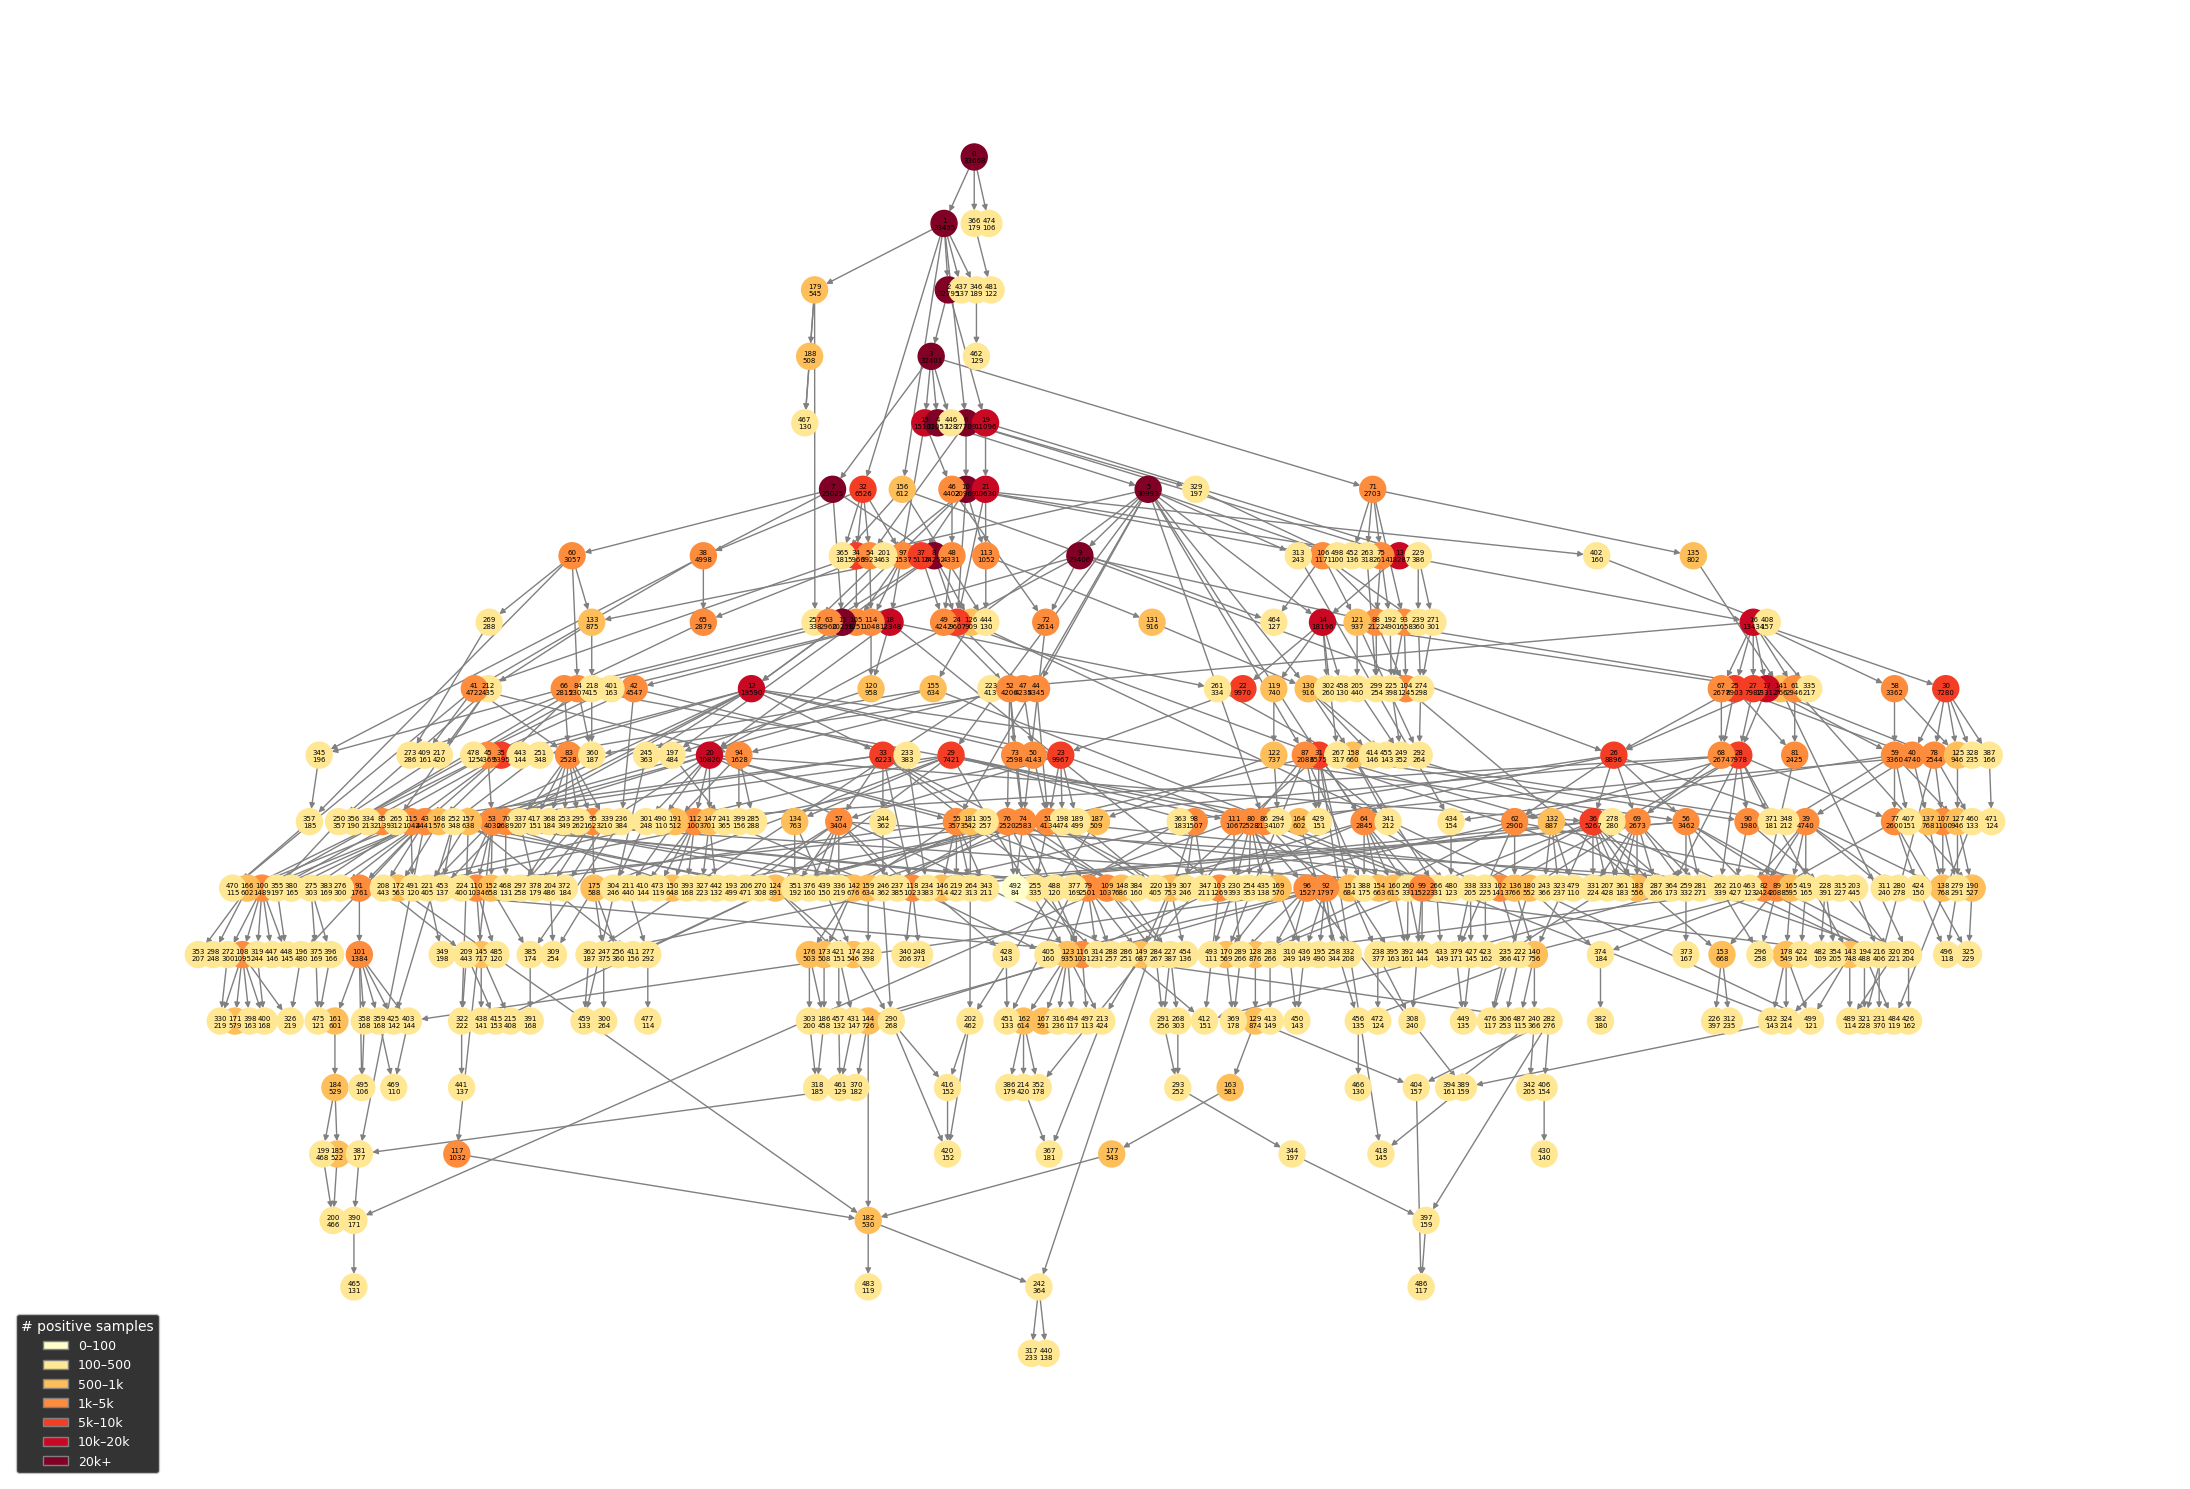

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# Count positives per class from training data
pos_counts = train_df[[c for c in train_df.columns if c.startswith("class_")]].sum()

node_list = list(G.nodes())
counts    = np.array([pos_counts.get(n, 0) for n in node_list], dtype=float)

# Discrete bins (log-spaced)
bins   = [0, 100, 500, 1000, 5000, 10000, 20000, counts.max() + 1]
labels_bins = ["0–100", "100–500", "500–1k", "1k–5k", "5k–10k", "10k–20k", "20k+"]
cmap   = plt.cm.YlOrRd
colors = [cmap(i / (len(bins) - 2)) for i in range(len(bins) - 1)]

def bin_color(c):
    for i in range(len(bins) - 1):
        if bins[i] <= c < bins[i + 1]:
            return colors[i]
    return colors[-1]

node_colors = [bin_color(c) for c in counts]

node_labels = {
    n: f"{n.replace('class_', '')}\n{int(pos_counts.get(n, 0))}"
    for n in node_list
}

fig, ax = plt.subplots(figsize=(22, 15))
pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
nx.draw(
    G, pos, ax=ax,
    nodelist=node_list,
    node_size=350,
    node_color=node_colors,
    edge_color="gray",
    arrows=True,
    arrowsize=8,
    with_labels=True,
    labels=node_labels,
    font_size=5,
)

legend_patches = [
    mpatches.Patch(facecolor=colors[i], edgecolor="gray", label=labels_bins[i])
    for i in range(len(labels_bins))
]
ax.legend(handles=legend_patches, title="# positive samples", loc="lower left", fontsize=9, title_fontsize=10)
ax.set_title("ChEBI class hierarchy — node color = # positive training samples", fontsize=13)
plt.tight_layout()
plt.show()

# Parse OBO → NetworkX DAG + topological sort

In [4]:
LABEL_COLS = [c for c in train_df.columns if c.startswith("class_")]

# Subgraph restricted to dataset classes, then topological sort
G_sub = G.subgraph(LABEL_COLS)
topo_order = list(nx.topological_sort(G_sub))

print(f"Topological order length: {len(topo_order)}")
print("First 10:", topo_order[:10])
print("Last  10:", topo_order[-10:])

# Build parents lookup from the subgraph for use during training
parents = {n: list(G_sub.predecessors(n)) for n in topo_order}

Topological order length: 500
First 10: ['class_0', 'class_1', 'class_366', 'class_474', 'class_156', 'class_179', 'class_2', 'class_32', 'class_346', 'class_437']
Last  10: ['class_199', 'class_367', 'class_242', 'class_483', 'class_465', 'class_397', 'class_200', 'class_317', 'class_440', 'class_486']


# Compute molecular fingerprints

In [5]:
%pip install scikit-fingerprints scikit-learn lightgbm -q

import warnings
import numpy as np
from rdkit import RDLogger
from skfp.fingerprints import (
    ECFPFingerprint,
    MACCSFingerprint,
    AtomPairFingerprint,
    TopologicalTorsionFingerprint,
    FunctionalGroupsFingerprint,
    MordredFingerprint,
)

warnings.filterwarnings("ignore", message="X does not have valid feature names")
RDLogger.DisableLog("rdApp.*")  # suppress RDKit C++ warnings

def smiles_to_features(smiles_list: list[str], n_jobs: int = -1) -> np.ndarray:
    """
    ECFP4/6/FCFP4 counts (with chirality) + MACCS counts
    + AtomPair counts + TopTorsion counts
    + FunctionalGroups counts + Mordred 2D descriptors
    ~12160 features total.
    """
    ecfp2     = ECFPFingerprint(fp_size=2048, radius=2, count=True, include_chirality=True, n_jobs=n_jobs)
    ecfp3     = ECFPFingerprint(fp_size=2048, radius=3, count=True, include_chirality=True, n_jobs=n_jobs)
    fcfp2     = ECFPFingerprint(fp_size=2048, radius=2, use_pharmacophoric_invariants=True, count=True, include_chirality=True, n_jobs=n_jobs)
    maccs     = MACCSFingerprint(count=True)                            # 158 features
    atom_pair = AtomPairFingerprint(fp_size=2048, count=True, n_jobs=n_jobs)
    torsion   = TopologicalTorsionFingerprint(fp_size=2048, count=True, n_jobs=n_jobs)
    funcgrp   = FunctionalGroupsFingerprint(count=True, n_jobs=n_jobs)  # 85 features
    mordred   = MordredFingerprint(use_3D=False, n_jobs=n_jobs)         # 1613 features

    return np.hstack([
        ecfp2.transform(smiles_list),
        ecfp3.transform(smiles_list),
        fcfp2.transform(smiles_list),
        maccs.transform(smiles_list),
        atom_pair.transform(smiles_list),
        torsion.transform(smiles_list),
        funcgrp.transform(smiles_list),
        mordred.transform(smiles_list),
    ]).astype(np.float32)

print("Computing train fingerprints...")
X_train_fp = smiles_to_features(train_df["SMILES"].tolist())

print("Computing test fingerprints...")
X_test_fp  = smiles_to_features(test_df["SMILES"].tolist())

print(f"X_train_fp: {X_train_fp.shape}, X_test_fp: {X_test_fp.shape}")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Computing train fingerprints...


/Users/blazejnowicki/miniconda3/envs/task1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:05] WARNING: not removing hydrogen atom without neighbors
[00:01:0

Computing test fingerprints...


[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:58] WARNING: not removing hydrogen atom without neighbors
[00:11:59] WARNING: not removing hydrogen atom without neighbors
[00:11:59] WARNING: not removing hydrogen atom without neighbors
[00:11:59] WARNING: not removing hydrogen atom without neighbors
[00:11:59] WARNING: not r

X_train_fp: (33668, 12095), X_test_fp: (11223, 12095)


# Hierarchical training in topological order

For each class (parents before children), we train a LightGBM binary classifier whose features are:
- Molecular fingerprint (2048 bits)
- Binary predictions of **all parent classes** (already computed in topo order)

At inference time the same parent predictions feed into each child classifier.

In [6]:
from lightgbm import LGBMClassifier

n_train = len(train_df)
n_test  = len(test_df)

cls_to_idx = {c: i for i, c in enumerate(LABEL_COLS)}

train_preds = np.zeros((n_train, len(LABEL_COLS)), dtype=np.float32)
test_preds  = np.zeros((n_test,  len(LABEL_COLS)), dtype=np.float32)

y_train_all = train_df[LABEL_COLS].values.astype(np.int8)

models = {}

for step, cls in enumerate(topo_order):
    idx = cls_to_idx[cls]
    y   = y_train_all[:, idx]

    parent_idxs = [cls_to_idx[p] for p in parents.get(cls, []) if p in cls_to_idx]

    if parent_idxs:
        X_tr = np.hstack([X_train_fp, train_preds[:, parent_idxs]])
        X_te = np.hstack([X_test_fp,  test_preds[:, parent_idxs]])
    else:
        X_tr = X_train_fp
        X_te = X_test_fp

    unique = np.unique(y)
    if len(unique) == 1:
        val = float(unique[0])
        train_preds[:, idx] = val
        test_preds[:,  idx] = val
        print(f"[{step:3d}/{len(topo_order)}] {cls} (constant={int(val)})")
        continue

    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    spw   = n_neg / n_pos

    clf = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=63,
        n_jobs=-1,
        verbose=-1,
    )
    clf.fit(X_tr, y)
    models[cls] = clf

    train_preds[:, idx] = clf.predict(X_tr).astype(np.float32)
    test_preds[:,  idx] = clf.predict(X_te).astype(np.float32)

    # If all parents are 0, the child must be 0 (hierarchical constraint)
    if parent_idxs:
        all_parents_zero_train = (train_preds[:, parent_idxs] == 0).all(axis=1)
        all_parents_zero_test  = (test_preds[:,  parent_idxs] == 0).all(axis=1)
        train_preds[all_parents_zero_train, idx] = 0
        test_preds[ all_parents_zero_test,  idx] = 0

    print(f"[{step:3d}/{len(topo_order)}] {cls}  pos={n_pos}  neg={n_neg}  spw={spw:.1f}  parents={len(parent_idxs)}")

print("Done training.")

[  0/500] class_0 (constant=1)
[  1/500] class_1  pos=33455  neg=213  spw=0.0  parents=1
[  2/500] class_366  pos=179  neg=33489  spw=187.1  parents=1
[  3/500] class_474  pos=106  neg=33562  spw=316.6  parents=1
[  4/500] class_156  pos=612  neg=33056  spw=54.0  parents=1
[  5/500] class_179  pos=545  neg=33123  spw=60.8  parents=1
[  6/500] class_2  pos=32795  neg=873  spw=0.0  parents=1
[  7/500] class_32  pos=6526  neg=27142  spw=4.2  parents=1
[  8/500] class_346  pos=189  neg=33479  spw=177.1  parents=1
[  9/500] class_437  pos=137  neg=33531  spw=244.8  parents=1
[ 10/500] class_6  pos=27709  neg=5959  spw=0.2  parents=1
[ 11/500] class_481  pos=122  neg=33546  spw=275.0  parents=1
[ 12/500] class_188  pos=508  neg=33160  spw=65.3  parents=1
[ 13/500] class_19  pos=11096  neg=22572  spw=2.0  parents=1
[ 14/500] class_3  pos=32401  neg=1267  spw=0.0  parents=1
[ 15/500] class_365  pos=181  neg=33487  spw=185.0  parents=2
[ 16/500] class_38  pos=4998  neg=28670  spw=5.7  parents=1

KeyboardInterrupt: 

# Evaluate on training set (self-check)

In [ ]:
from sklearn.metrics import f1_score

micro = f1_score(y_train_all, train_preds.astype(int), average="micro", zero_division=0)
macro = f1_score(y_train_all, train_preds.astype(int), average="macro", zero_division=0)
print(f"Train micro-F1: {micro:.4f}")
print(f"Train macro-F1: {macro:.4f}")

# Build submission & submit

In [ ]:
pred_df = pd.DataFrame(test_preds.astype(np.int64), columns=LABEL_COLS)
submission_df = pd.concat([test_df[["mol_id", "SMILES"]].reset_index(drop=True), pred_df], axis=1)

SUBMISSION_FILE = "submission5.parquet"
submission_df.to_parquet(SUBMISSION_FILE, index=False)
print(f"Saved {SUBMISSION_FILE}  shape={submission_df.shape}")
submission_df.head()

In [ ]:
import io, os, requests
from dotenv import load_dotenv

load_dotenv()
API_TOKEN  = os.getenv("TEAM_TOKEN")
SERVER_URL = os.getenv("SERVER_URL")

buffer = io.BytesIO()
submission_df.to_parquet(buffer, index=False)
buffer.seek(0)

response = requests.post(
    f"{SERVER_URL}/task1",
    files={"parquet_file": buffer},
    headers={"X-API-Token": API_TOKEN},
)

try:
    data = response.json()
except Exception:
    data = response.text

print("Status:",   response.status_code)
print("Response:", data)